In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Dataset 1: Credit Card Customer Data

In [2]:
df_cc = pd.read_csv('Credit Card Customer Data.csv', sep=';')
df_cc.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [3]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [4]:
df_cc.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [5]:
print('Valores nulos por columna:')
print(df_cc.isnull().sum())
print(f'\nDuplicados: {df_cc.duplicated().sum()}')

Valores nulos por columna:
Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

Duplicados: 0


In [6]:
# Preprocesamiento: seleccionar features numéricas relevantes y eliminar identificadores
features_cc = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
X_cc = df_cc[features_cc].copy()

# Imputar nulos con la mediana si existieran
X_cc.fillna(X_cc.median(), inplace=True)

# Escalar
scaler_cc = StandardScaler()
X_cc_scaled = scaler_cc.fit_transform(X_cc)
print('Shape tras preprocesamiento:', X_cc_scaled.shape)

Shape tras preprocesamiento: (660, 5)


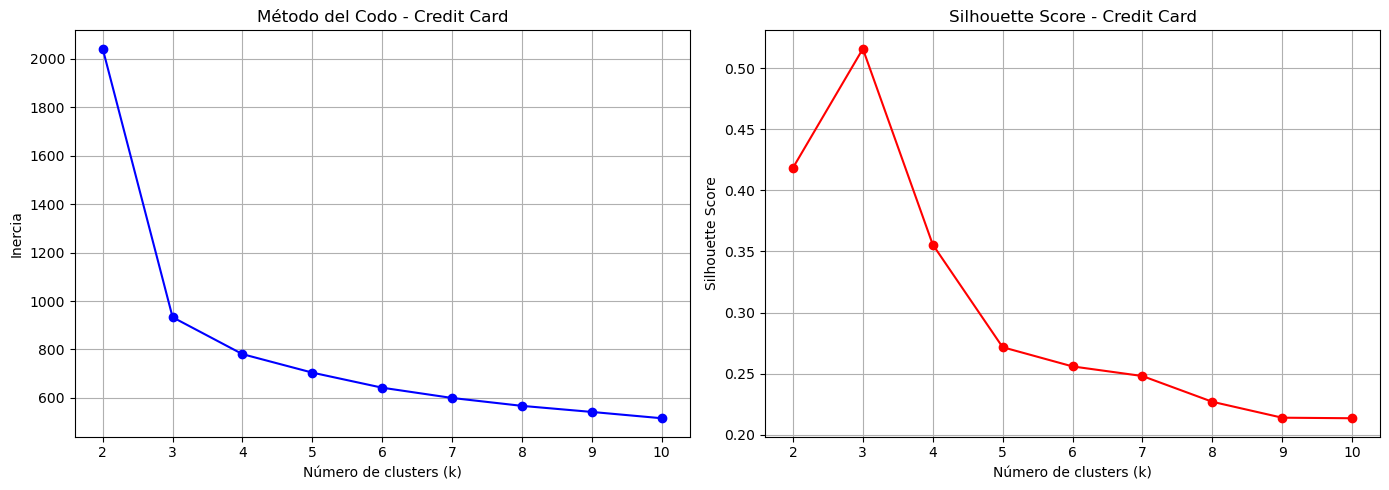

Mejor k según Silhouette: 3 (score=0.5157)


In [7]:
# Método del codo para determinar k óptimo
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cc_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cc_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - Credit Card')
axes[0].grid(True)

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Credit Card')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k_cc = K_range[np.argmax(sil_scores)]
print(f'Mejor k según Silhouette: {best_k_cc} (score={max(sil_scores):.4f})')

In [8]:
# Entrenar modelo K-Means con el k seleccionado
kmeans_cc = KMeans(n_clusters=best_k_cc, random_state=42, n_init=10)
df_cc['Cluster'] = kmeans_cc.fit_predict(X_cc_scaled)

print('Distribución de clusters:')
print(df_cc['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0    386
1     50
2    224
Name: count, dtype: int64


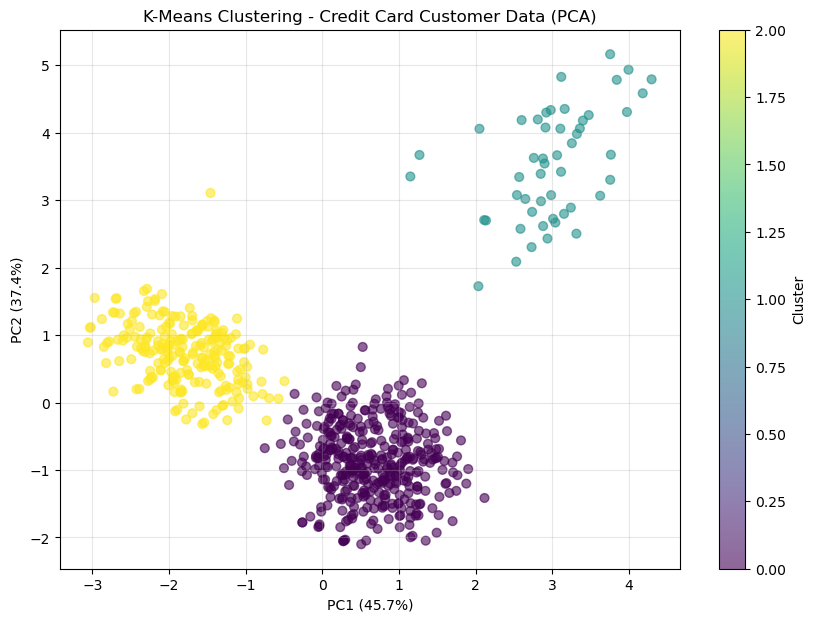

In [9]:
# Visualización con PCA (2 componentes)
pca_cc = PCA(n_components=2)
X_cc_pca = pca_cc.fit_transform(X_cc_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_cc_pca[:, 0], X_cc_pca[:, 1], c=df_cc['Cluster'], cmap='viridis', alpha=0.6, s=40)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_cc.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_cc.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clustering - Credit Card Customer Data (PCA)')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Perfil de cada cluster
print('Perfil promedio por cluster:')
df_cc.groupby('Cluster')[features_cc].mean().round(2)

Perfil promedio por cluster:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33782.38,5.52,3.49,0.98,2.00
1,141040.00,8.74,0.60,10.90,1.08
2,12174.11,2.41,0.93,3.55,6.87


# Dataset 2: World Development Data (Imputed)

In [11]:
df_imp = pd.read_csv('world_development_data_imputed.csv')
df_imp.head()

,Year,Country,Region,SubRegion,SurfAreaSqKm,PopTotal,PopDens,PopGrowth%,GDP,GDPGrowth%,...,GNIAtlas,Imports%GDP,IndValAdd%GDP,InflConsPric%,LifeExpBirth,MerchTrade%GDP,MobileSubs/100,MortRateU5,NetMigr,UrbanPopGrowth%
0,2000.0,Afghanistan,Asia,Southern Asia,652860.0,19542982.0,29.963329,1.443803,1.801248e+10,-5.206288,...,1.778669e+10,41.312634,17.178775,37.611028,55.298000,52.777048,0.000000,129.3,-1007135.0,1.861377
1,2000.0,Malta,Europe,Southern Europe,320.0,390087.0,1219.021875,0.645267,4.323339e+09,19.681791,...,4.273280e+09,128.374581,26.939987,-4.512396,78.348780,135.682159,28.667475,7.6,1799.0,0.952299
2,2000.0,Belgium,Europe,Western Europe,30530.0,10251250.0,338.548547,0.242518,2.367925e+11,3.716679,...,2.654129e+11,69.682740,24.943833,2.014617,77.721951,154.515900,54.840339,5.9,32262.0,0.308431
3,2000.0,Marshall Islands,Oceania,Micronesia,180.0,54224.0,301.244444,0.721838,1.153475e+08,1.354079,...,1.500075e+08,100.812761,12.681072,-0.454689,63.275000,55.484514,0.824358,42.1,-1323.0,1.492787
4,2000.0,Mauritania,Africa,Sub-Saharan Africa,1030700.0,2695003.0,2.614731,2.799182,1.779521e+09,-3.918026,...,1.907497e+09,33.423259,29.951850,6.351587,61.028000,45.461676,0.567717,98.8,-2997.0,2.476860


In [12]:
df_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4444 entries, 0 to 4443
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             4444 non-null   float64
 1   Country          4444 non-null   object 
 2   Region           4444 non-null   object 
 3   SubRegion        4444 non-null   object 
 4   SurfAreaSqKm     4444 non-null   float64
 5   PopTotal         4444 non-null   float64
 6   PopDens          4444 non-null   float64
 7   PopGrowth%       4444 non-null   float64
 8   GDP              4444 non-null   float64
 9   GDPGrowth%       4444 non-null   float64
 10  AdolFertRate     4444 non-null   float64
 11  AgriValAdd%GDP   4444 non-null   float64
 12  Exports%GDP      4444 non-null   float64
 13  FertRate         4444 non-null   float64
 14  FDINetBoP        4444 non-null   float64
 15  GNI/CapAtlas     4444 non-null   float64
 16  GNIAtlas         4444 non-null   float64
 17  Imports%GDP   

In [13]:
df_imp.describe()

,Year,SurfAreaSqKm,PopTotal,PopDens,PopGrowth%,GDP,GDPGrowth%,AdolFertRate,AgriValAdd%GDP,Exports%GDP,...,GNIAtlas,Imports%GDP,IndValAdd%GDP,InflConsPric%,LifeExpBirth,MerchTrade%GDP,MobileSubs/100,MortRateU5,NetMigr,UrbanPopGrowth%
count,4444.000000,4.444000e+03,4.444000e+03,4444.000000,4444.000000,4.444000e+03,4444.000000,4444.000000,4444.000000,4444.000000,...,4.444000e+03,4444.000000,4444.000000,4444.000000,4444.000000,4444.000000,4444.000000,4444.000000,4.444000e+03,4444.000000
mean,2010.500000,6.640703e+05,3.445608e+07,312.879045,1.374862,3.194480e+11,3.268364,53.469415,10.962849,44.263785,...,3.166865e+11,50.468908,25.721662,7.500906,70.230413,64.729675,77.088754,37.743370,2.013533e+02,2.034387
std,6.345003,1.888320e+06,1.331737e+08,1501.365686,1.542070,1.411696e+12,5.749729,43.480988,11.195331,29.124115,...,1.417688e+12,27.432700,12.395006,43.558717,8.773385,41.686167,50.754239,39.387756,1.764569e+05,1.960524
min,2000.000000,2.000000e+01,9.609000e+03,0.136492,-6.852118,1.396473e+07,-54.235900,1.493000,0.012519,2.249870,...,2.535845e+07,1.877678,2.758632,-30.199654,41.957000,7.805932,0.000000,2.000000,-2.290411e+06,-8.830483
25%,2005.000000,1.782000e+04,1.231632e+06,31.308813,0.425132,4.558559e+09,1.099784,17.225750,2.088816,24.622995,...,4.199838e+09,30.200552,17.387792,1.442125,64.433500,40.191608,32.957354,9.200000,-2.015975e+04,0.649020
50%,2010.500000,1.113700e+05,6.469593e+06,79.320522,1.255840,1.977252e+10,3.494868,41.599000,6.979923,38.530971,...,1.843209e+10,44.884701,23.565796,3.713096,72.027415,55.318351,80.917939,23.100000,-9.945000e+02,1.859358
75%,2016.000000,5.053700e+05,2.230908e+07,184.349845,2.267222,1.288408e+11,5.857273,77.742000,17.192146,60.796237,...,1.246401e+11,66.561876,30.813010,7.945621,76.809049,77.437441,114.777618,52.200000,1.032225e+04,3.211583
max,2021.000000,1.709825e+07,1.412360e+09,21594.800000,19.360429,2.331508e+13,86.826748,205.385000,79.042362,228.993771,...,2.353992e+13,221.009959,86.669555,2630.122674,85.497561,420.661372,420.853098,228.500000,1.479676e+06,19.612031


In [14]:
print('Valores nulos por columna:')
print(df_imp.isnull().sum())
print(f'\nDuplicados: {df_imp.duplicated().sum()}')
print(f'\nShape: {df_imp.shape}')

Valores nulos por columna:
Year               0
Country            0
Region             0
SubRegion          0
SurfAreaSqKm       0
PopTotal           0
PopDens            0
PopGrowth%         0
GDP                0
GDPGrowth%         0
AdolFertRate       0
AgriValAdd%GDP     0
Exports%GDP        0
FertRate           0
FDINetBoP          0
GNI/CapAtlas       0
GNIAtlas           0
Imports%GDP        0
IndValAdd%GDP      0
InflConsPric%      0
LifeExpBirth       0
MerchTrade%GDP     0
MobileSubs/100     0
MortRateU5         0
NetMigr            0
UrbanPopGrowth%    0
dtype: int64

Duplicados: 0

Shape: (4444, 26)


In [15]:
# Preprocesamiento
# Seleccionar solo columnas numéricas, excluyendo Year
cols_excluir_imp = ['Year', 'Country', 'Region', 'SubRegion']
num_cols_imp = [c for c in df_imp.columns if c not in cols_excluir_imp and df_imp[c].dtype in ['float64', 'int64']]

X_imp = df_imp[num_cols_imp].copy()

# Imputar nulos con la mediana
X_imp.fillna(X_imp.median(), inplace=True)

# Eliminar filas que aún tengan NaN (columnas 100% vacías)
X_imp.dropna(axis=1, how='all', inplace=True)

# Escalar
scaler_imp = StandardScaler()
X_imp_scaled = scaler_imp.fit_transform(X_imp)

print(f'Features seleccionadas: {X_imp.shape[1]}')
print(f'Registros: {X_imp.shape[0]}')

Features seleccionadas: 22
Registros: 4444


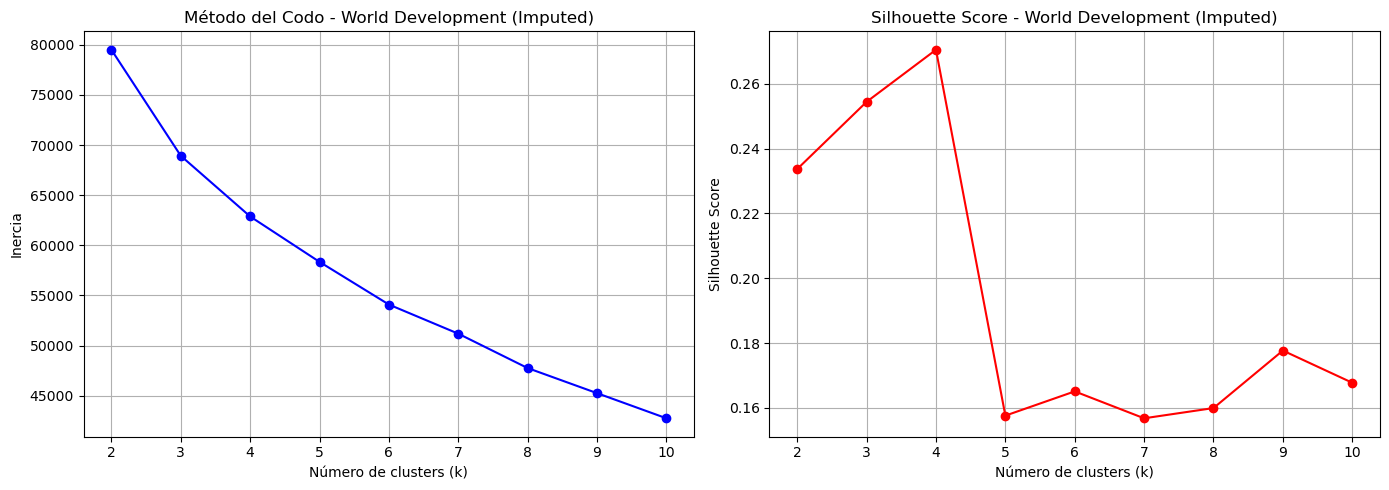

Mejor k según Silhouette: 4 (score=0.2705)


In [16]:
# Método del codo
inertias_imp = []
sil_imp = []
K_range_imp = range(2, 11)

for k in K_range_imp:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_imp_scaled)
    inertias_imp.append(km.inertia_)
    sil_imp.append(silhouette_score(X_imp_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_imp, inertias_imp, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - World Development (Imputed)')
axes[0].grid(True)

axes[1].plot(K_range_imp, sil_imp, 'ro-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - World Development (Imputed)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k_imp = K_range_imp[np.argmax(sil_imp)]
print(f'Mejor k según Silhouette: {best_k_imp} (score={max(sil_imp):.4f})')

In [17]:
# Entrenar K-Means
kmeans_imp = KMeans(n_clusters=best_k_imp, random_state=42, n_init=10)
df_imp['Cluster'] = kmeans_imp.fit_predict(X_imp_scaled)

print('Distribución de clusters:')
print(df_imp['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0    2993
1    1348
2      66
3      37
Name: count, dtype: int64


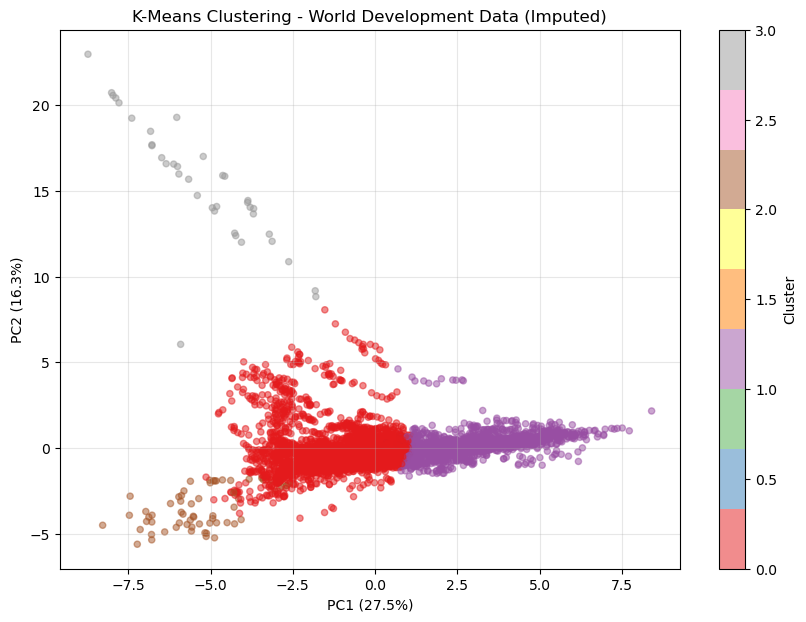

In [18]:
# Visualización PCA
pca_imp = PCA(n_components=2)
X_imp_pca = pca_imp.fit_transform(X_imp_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_imp_pca[:, 0], X_imp_pca[:, 1], c=df_imp['Cluster'], cmap='Set1', alpha=0.5, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_imp.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_imp.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clustering - World Development Data (Imputed)')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Países representativos por cluster
print('Países por cluster (muestra):')
for c in sorted(df_imp['Cluster'].unique()):
    paises = df_imp[df_imp['Cluster'] == c]['Country'].unique()[:5]
    print(f'  Cluster {c}: {", ".join(paises)}')

Países por cluster (muestra):
  Cluster 0: Malta, Belgium, Mauritius, Mexico, Micronesia, Fed. Sts.
  Cluster 1: Afghanistan, Marshall Islands, Mauritania, Mali, Mozambique
  Cluster 2: Macao SAR, China, Hong Kong SAR, China, Singapore
  Cluster 3: United States, Netherlands, China


# Dataset 3: World Development Data (Interpolated)

In [20]:
df_inter = pd.read_csv('world_development_data_interpolated.csv')
df_inter.head()

,Year,Country,Region,SubRegion,IntermRegion,SurfAreaSqKm,PopDens,PopGrowth%,GDP,GDPGrowth%,...,MerchTrade%GDP,MilExp%GDP,MobileSubs/100,MortRateU5,NetMigr,PopTotal,RevenueExGrants%GDP,SchEnrollPrim%,TaxRevenue%GDP,UrbanPopGrowth%
0,1973,Afghanistan,Asia,Southern Asia,NaN,652860.0,17.747275,2.524421,1.733333e+09,NaN,...,18.173078,1.868910,NaN,285.2,-3030.0,11575305.0,NaN,35.214371,NaN,5.688982
1,1973,Netherlands,Europe,Western Europe,NaN,41530.0,398.084182,0.827331,7.184091e+10,5.444223,...,78.083644,2.702997,NaN,14.1,31535.0,13439322.0,38.294098,100.047302,22.460626,1.337022
2,1973,Poland,Europe,Eastern Europe,NaN,312690.0,108.907245,0.908114,NaN,NaN,...,NaN,NaN,NaN,30.5,-28055.0,33357200.0,NaN,105.338722,NaN,2.125265
3,1973,"Egypt, Arab Rep.",Africa,Northern Africa,NaN,1001450.0,37.290448,2.151183,1.009853e+10,3.506830,...,20.161341,13.513514,NaN,232.5,-112685.0,37120776.0,NaN,70.221947,NaN,3.007695
4,1973,Gabon,Africa,Sub-Saharan Africa,Middle Africa,267670.0,2.465510,2.067382,7.227807e+08,10.182434,...,72.082722,1.303538,NaN,149.4,613.0,635288.0,NaN,130.283417,NaN,7.959430


In [21]:
df_inter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9947 entries, 0 to 9946
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 9947 non-null   int64  
 1   Country              9947 non-null   object 
 2   Region               9947 non-null   object 
 3   SubRegion            9947 non-null   object 
 4   IntermRegion         4214 non-null   object 
 5   SurfAreaSqKm         9900 non-null   float64
 6   PopDens              9297 non-null   float64
 7   PopGrowth%           9929 non-null   float64
 8   GDP                  8668 non-null   float64
 9   GDPGrowth%           8424 non-null   float64
 10  AdolFertRate         9947 non-null   float64
 11  AgriValAdd%GDP       7496 non-null   float64
 12  DomCredit%GDP        1185 non-null   float64
 13  Exports%GDP          7434 non-null   float64
 14  FertRate             9746 non-null   float64
 15  FDINetBoP            8557 non-null   f

In [22]:
df_inter.describe()

,Year,SurfAreaSqKm,PopDens,PopGrowth%,GDP,GDPGrowth%,AdolFertRate,AgriValAdd%GDP,DomCredit%GDP,Exports%GDP,...,MerchTrade%GDP,MilExp%GDP,MobileSubs/100,MortRateU5,NetMigr,PopTotal,RevenueExGrants%GDP,SchEnrollPrim%,TaxRevenue%GDP,UrbanPopGrowth%
count,9947.000000,9.900000e+03,9297.000000,9929.000000,8.668000e+03,8424.000000,9947.000000,7496.000000,1185.000000,7434.000000,...,8333.000000,6433.000000,9196.000000,9133.00000,9.947000e+03,9.930000e+03,4174.000000,7930.000000,4228.000000,9929.000000
mean,1997.000000,6.630547e+05,280.543721,1.644351,2.169398e+11,3.431273,68.044462,14.540608,74.901322,37.581694,...,62.166119,2.647866,37.740162,61.55063,2.068051e+02,2.878674e+07,26.019826,97.603393,16.859607,2.586991
std,14.142847,1.882568e+06,1399.257023,1.685601,1.080045e+12,6.312911,49.976502,13.222968,64.719506,27.835297,...,48.606261,3.196583,52.112028,64.64795,1.598394e+05,1.151345e+08,15.120381,20.891500,7.845912,3.090308
min,1973.000000,2.000000e+01,0.136436,-27.722225,8.824746e+06,-64.047107,1.493000,0.012519,-9.313642,0.005377,...,2.705383,0.000017,0.000000,2.00000,-2.290411e+06,5.934000e+03,0.000110,8.447979,0.000079,-189.743417
25%,1985.000000,1.782000e+04,21.990052,0.592861,2.258169e+09,1.089462,26.686000,3.701222,32.908970,19.605817,...,36.516889,1.165185,0.000000,14.50000,-1.735700e+04,8.555462e+05,17.152083,93.630156,11.662240,0.967370
50%,1997.000000,1.109950e+05,66.804721,1.579620,1.130180e+10,3.636124,56.742000,10.382376,55.501759,30.522527,...,51.797371,1.835760,1.969659,35.00000,-9.140000e+02,5.188308e+06,24.457191,101.043663,16.239222,2.350129
75%,2009.000000,4.881000e+05,154.633106,2.586997,7.006243e+10,6.058192,98.847500,22.717535,90.213762,47.673590,...,75.107875,3.086861,78.245463,89.30000,7.127500e+03,1.673941e+07,33.094809,107.771225,21.494044,3.926864
max,2021.000000,1.709825e+07,21594.800000,19.360429,2.331508e+13,149.972963,236.489000,79.042362,391.083089,228.993771,...,957.784011,117.349823,420.853098,358.50000,1.866819e+06,1.412360e+09,345.040192,216.497162,147.661240,52.476419


In [23]:
print('Valores nulos por columna:')
print(df_inter.isnull().sum())
print(f'\nDuplicados: {df_inter.duplicated().sum()}')
print(f'\nShape: {df_inter.shape}')

Valores nulos por columna:
Year                      0
Country                   0
Region                    0
SubRegion                 0
IntermRegion           5733
SurfAreaSqKm             47
PopDens                 650
PopGrowth%               18
GDP                    1279
GDPGrowth%             1523
AdolFertRate              0
AgriValAdd%GDP         2451
DomCredit%GDP          8762
Exports%GDP            2513
FertRate                201
FDINetBoP              1390
GNI/CapAtlas           2080
GNIAtlas               2079
GrossCapForm%GDP       2768
Imports%GDP            2513
IndValAdd%GDP          2502
InflConsPric%          1550
LifeExpBirth            207
MerchTrade%GDP         1614
MilExp%GDP             3514
MobileSubs/100          751
MortRateU5              814
NetMigr                   0
PopTotal                 17
RevenueExGrants%GDP    5773
SchEnrollPrim%         2017
TaxRevenue%GDP         5719
UrbanPopGrowth%          18
dtype: int64

Duplicados: 0

Shape: (9947, 33)


In [24]:
# Preprocesamiento
cols_excluir_inter = ['Year', 'Country', 'Region', 'SubRegion', 'IntermRegion']
num_cols_inter = [c for c in df_inter.columns if c not in cols_excluir_inter and df_inter[c].dtype in ['float64', 'int64']]

X_inter = df_inter[num_cols_inter].copy()

# Imputar nulos con la mediana
X_inter.fillna(X_inter.median(), inplace=True)

# Eliminar columnas con varianza 0
X_inter = X_inter.loc[:, X_inter.std() > 0]

# Escalar
scaler_inter = StandardScaler()
X_inter_scaled = scaler_inter.fit_transform(X_inter)

print(f'Features seleccionadas: {X_inter.shape[1]}')
print(f'Registros: {X_inter.shape[0]}')

Features seleccionadas: 28
Registros: 9947


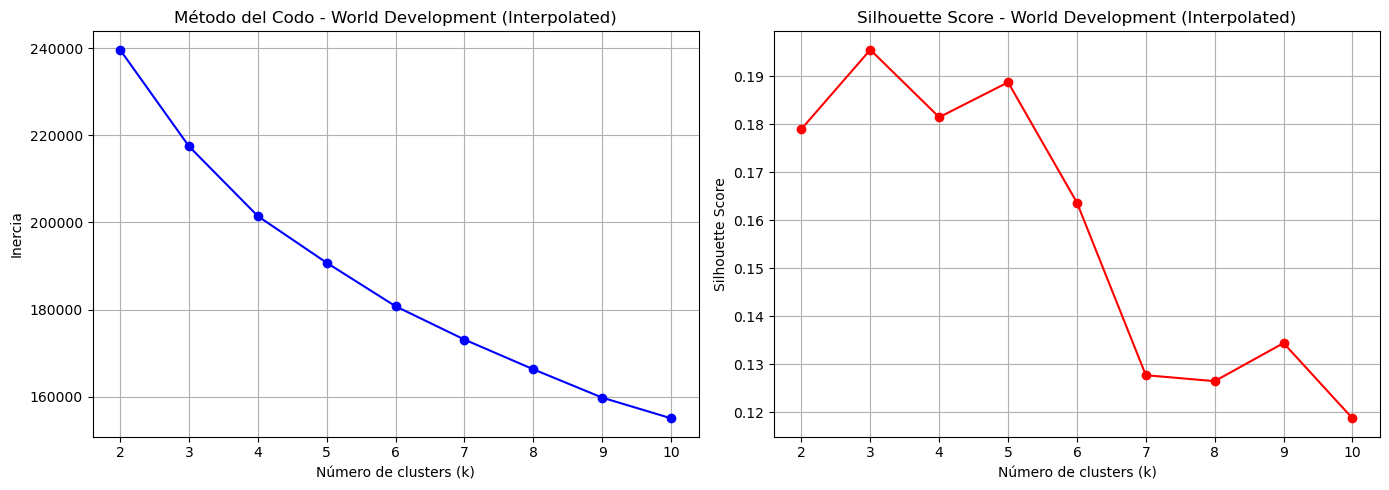

Mejor k según Silhouette: 3 (score=0.1955)


In [25]:
# Método del codo
inertias_inter = []
sil_inter = []
K_range_inter = range(2, 11)

for k in K_range_inter:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_inter_scaled)
    inertias_inter.append(km.inertia_)
    sil_inter.append(silhouette_score(X_inter_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_inter, inertias_inter, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - World Development (Interpolated)')
axes[0].grid(True)

axes[1].plot(K_range_inter, sil_inter, 'ro-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - World Development (Interpolated)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k_inter = K_range_inter[np.argmax(sil_inter)]
print(f'Mejor k según Silhouette: {best_k_inter} (score={max(sil_inter):.4f})')

In [26]:
# Entrenar K-Means
kmeans_inter = KMeans(n_clusters=best_k_inter, random_state=42, n_init=10)
df_inter['Cluster'] = kmeans_inter.fit_predict(X_inter_scaled)

print('Distribución de clusters:')
print(df_inter['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0      81
1    3277
2    6589
Name: count, dtype: int64


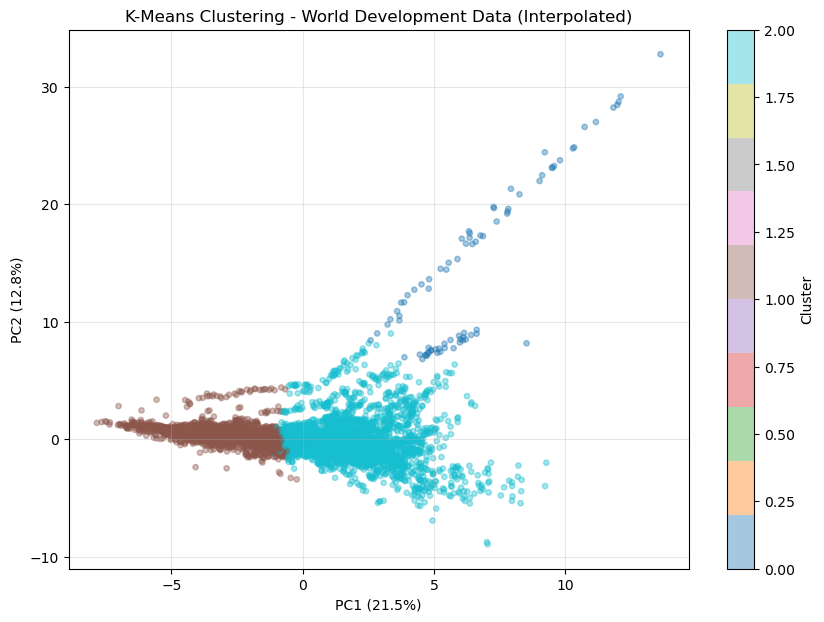

In [27]:
# Visualización PCA
pca_inter = PCA(n_components=2)
X_inter_pca = pca_inter.fit_transform(X_inter_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_inter_pca[:, 0], X_inter_pca[:, 1], c=df_inter['Cluster'], cmap='tab10', alpha=0.4, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_inter.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_inter.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clustering - World Development Data (Interpolated)')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Países representativos por cluster
print('Países por cluster (muestra):')
for c in sorted(df_inter['Cluster'].unique()):
    paises = df_inter[df_inter['Cluster'] == c]['Country'].unique()[:5]
    print(f'  Cluster {c}: {", ".join(paises)}')

Países por cluster (muestra):
  Cluster 0: United States, Japan, Netherlands, China
  Cluster 1: Afghanistan, Egypt, Arab Rep., Gabon, United Arab Emirates, Viet Nam
  Cluster 2: Netherlands, Poland, Antigua and Barbuda, Spain, Israel


In [29]:
# Comparación de regiones por cluster
ct = pd.crosstab(df_inter['Region'], df_inter['Cluster'], normalize='index').round(3)
ct.style.background_gradient(cmap='YlOrRd', axis=1)

Cluster,0,1,2
Region,,,
Africa,0.000000,0.784000,0.216000
Americas,0.018000,0.151000,0.832000
Asia,0.018000,0.317000,0.665000
Europe,0.000000,0.000000,1.000000
Oceania,0.000000,0.205000,0.795000
